# Wide Deep Learning

## Architecture

As mentioned earlier, Wide and Deep models are used to combine the strength of memorization and generalization but there are 2 major challenges:

1) Achieving Memorization
2) achieving generalization

Before understanding the architecture of wide and deep models few basic terminologies are listed as given below:

Memorization:  In the context of Machine Learning, memorization is the ability of machine to learn the frequently co-occurring items and then finding the correlation between the items from historical data.

Generalization: The ability of the machine to probe for the new feature combinations for the purpose of recognizing/identifying the new sample that the machine had never or rarely seen in the past based on transitivity of correlation is called as Generalization.
Wide learning: It is a special type of machine learning used to handle imbalanced data sets with highest accuracy.
 Width and depth of neural network:

_‘h’_ – depth of a network = number of layers (including output layer but excluding input layer)      

_‘w’_ - width of a network = maximum number of nodes in a layer.       

Let us understand the working of Wide and deep learning by considering Google play app recommender system. The contemporary recommenders are based on memorization i.e., based on the actions performed by the users, the relevant items are directly searched.  Generalized linear models are more suitable to build recommendation system for industries having massive-online transactions. Such a system uses logistic regression because they are simple, scalable and interpretable. For example, when user purchase the “Machine learning” book, then recommender memorizes it. Further, the recommender, generalizes by exploring the best combination of next item with Machine learning book, like deep learning book, statistics book. This accomplished by 3 steps which is explained below.

## Wide Model

- The recommender receives a query from the user for an app.
- Machine should be able to memorize which app should be selected for each query
- Let, Q= query by user for an app, F= set of features the helps in prediction and T= Target label like whether the app is accepted by user or not.
- Suppose, Q= “My talking Tom 2” a query for game by user, f= set of features from the data which can help in predicting the target variable. The ideas is to design machine learning based recommender system which can search for the apps that are close to the query and recommend it for user. Suppose the recommender finds “My Talking Tom2“, “My talking Tom gold” game and the user accept it then T=1.
- First linear model is trained. Linear regression ca be the chosen with an extensive transformed feature set. This can be used to find the correlation between the pair Q, F with T.
- The model predicts the probability of acceptance defined as  -> P(acceptance | Q, I) , where I is recommended item.
- For each query Q, there can be many items-I.
- Performance of wide model can be measured by goodness of Memorizing which is further dependent what users likes and accepts and it begins to get more purchase.

![alt text](5201600927365914.jpg)

## Deep Model

Suppose many users are eager to see new exciting recommendation that can surprise them other than the regular recommendations. Then, deep model is trained in lower-dimensional dense space with a pair of (query, item). This makes the machine able to generalize by matching apps to queries that are near to each other in the data space.

![alt text](5211600927456786.jpg)

## Wide Model + Deep Model

Overfitting is a very well-known problem in Deep learning. This occurs when deep neural network sometimes generalizes too much (overfitting) from the memorized or learned data. Due to overfitting problem, the recommender may recommend many unrelated items or apps. This may be due to the presence of two distinct types of query-item relationships in the data. Initially, the queries are very specific to user’s interest. Later, the queries that requires probing become more generalized. Consequently, the system starts searching for different set of related items. Having realized this both the models are combined.

To mitigate the prediction errors that occurs during the training, backpropagation of error is used at both sides to train the model parameters.

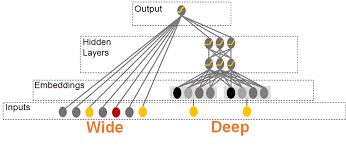

[Research Article](https://ai.googleblog.com/2016/06/wide-deep-learning-better-together-with.html)

---

# Problem statement: To predict the income of a US population using Census data set.

Data set description: UCI Census Income Data Set details as listed in below given table.

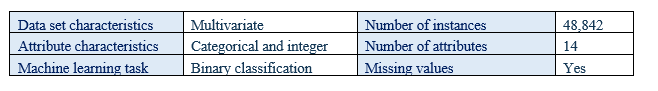

[Download Dataset](https://archive.ics.uci.edu/dataset/20/census+income)

Following steps can be followed to implement wide and deep learning. Logistic regression is used to train the linear model to predict the income of a person using the census dataset.  TensorFlow is used to demonstrate the Wide and Deep Learning on Census data set.

   - _< tf.estimator>_ API is used to train a linear model (wide) along with a deep neural network so that, both memorization and generalization features an be achieved.
   - **Wide model features:** They are used to select the base features(columns) and crossed columns.
   - **Deep model features:** Choosing the continuous columns, the dimension for each categorical column, and hidden layer sizes.
   - Combining wide and deep models into a single model using _<DNNLinearCombinedClassifier.>_ API.

[To know more about TensorFlow APIs](https://www.tensorflow.org/api_docs/python/tf/keras/experimental/WideDeepModel)

## Installing Packages

In [1]:
# In newer versions, the estimator module has been moved to a separate package. And Keras is now integrated into TensorFlow to avoid compatibility issues for creating wide & deep models. Also the code was massively huge but Keras has simplified it a lot.

%pip install tensorflow keras pandas numpy 

Note: you may need to restart the kernel to use updated packages.


## Importing Libraries

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

2025-06-19 19:15:09.964478: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-19 19:15:09.968138: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-19 19:15:09.977155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750360509.991294   27116 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750360509.995571   27116 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750360510.007774   27116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Set the TRAIN_DATA AND EVAL_DATA variables to your local file paths.

In [3]:
TRAIN_DATA = 'census+income/adult.data'
EVAL_DATA = 'census+income/adult.test'

## Define Feature Lists

In [4]:
# Numeric and categorical features
NUMERIC_FEATURES = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
CATEGORICAL_FEATURES = ["education", "marital_status", "relationship", "workclass", "occupation"]

## Loading & Preprocessing Data

In [5]:
column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income"
]
train_df = pd.read_csv(TRAIN_DATA, names=column_names, na_values=" ?", skipinitialspace=True)
test_df = pd.read_csv(EVAL_DATA, names=column_names, skiprows=1, na_values=" ?", skipinitialspace=True)
train_df = train_df.dropna()
test_df = test_df.dropna()
train_df["income"] = train_df["income"].apply(lambda x: 1 if ">50K" in x else 0)
test_df["income"] = test_df["income"].apply(lambda x: 1 if ">50K" in x else 0)

## Keras Inputs

In [7]:
inputs = {}
for col in NUMERIC_FEATURES:
    inputs[col] = keras.Input(shape=(1,), name=col)
for col in CATEGORICAL_FEATURES:
    inputs[col] = keras.Input(shape=(1,), name=col, dtype=tf.string)

## Wide part of the mode ( One-hot categorical features )

In [8]:
wide_parts = []
for col in CATEGORICAL_FEATURES:
    lookup = layers.StringLookup(vocabulary=np.unique(train_df[col]))
    one_hot = layers.CategoryEncoding(num_tokens=lookup.vocabulary_size(), output_mode="one_hot")(lookup(inputs[col]))
    wide_parts.append(one_hot)
wide = layers.concatenate(wide_parts)

2025-06-19 19:15:13.293554: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Deep model: neural network with embedding

In [9]:
deep_parts = [inputs[col] for col in NUMERIC_FEATURES]
for col in CATEGORICAL_FEATURES:
    lookup = layers.StringLookup(vocabulary=np.unique(train_df[col]))
    embed = layers.Embedding(input_dim=lookup.vocabulary_size(), output_dim=4)(lookup(inputs[col]))
    deep_parts.append(layers.Flatten()(embed))
deep = layers.concatenate(deep_parts)
deep = layers.Dense(128, activation="relu")(deep)
deep = layers.Dense(64, activation="relu")(deep)

## Combining wide and deep model

_tf. estimator_ is a pre-made **Estimator** class. Example,  _<tf. Estimator.Classifier>_ can be used to train the classification models based on dense, feed-forward neural networks. This API can be used to develop a good model with high-level in-built code with ease. **Estimators** are built on tf. keras. layers, that makes customization a lot easier.

In [10]:
combined = layers.concatenate([wide, deep])
output = layers.Dense(1, activation="sigmoid")(combined)
model = keras.Model(inputs=inputs, outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

## Training and evaluating the model

In [11]:
# Prepare the data for Keras
def df_to_dict(df):
    return {col: df[col].values for col in NUMERIC_FEATURES + CATEGORICAL_FEATURES}

X_train = df_to_dict(train_df)
y_train = train_df["income"].values
X_test = df_to_dict(test_df)
y_test = test_df["income"].values

# Train & evaluate the model
model.fit(X_train, y_train, epochs=5, batch_size=256, validation_data=(X_test, y_test))

Epoch 1/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7654 - loss: 4.2511 - val_accuracy: 0.8220 - val_loss: 0.7849
Epoch 2/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8230 - loss: 0.7730 - val_accuracy: 0.8318 - val_loss: 0.5544
Epoch 3/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8348 - loss: 0.5716 - val_accuracy: 0.8318 - val_loss: 0.5176
Epoch 4/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8369 - loss: 0.5812 - val_accuracy: 0.8352 - val_loss: 0.7138
Epoch 5/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8372 - loss: 0.8297 - val_accuracy: 0.8147 - val_loss: 2.9843


## Output

In [17]:
print("First 5 rows:")
train_df.head()

First 5 rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [18]:
print("\nLast 5 rows:")
train_df.tail()


Last 5 rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,1
